# Sesión 3: Redes Neuronales y PyTorch
Guido Anthony Chipana Calderon

---

### Objetivos de la sesión:
1. Comprender el perceptrón y neuronas artificiales
2. Implementar funciones de activación desde cero
3. Entender forward y backpropagation matemáticamente
4. Dominar PyTorch: tensores, autograd, nn.Module
5. Entrenar tu primera red neuronal para clasificación
6. Visualizar el proceso de aprendizaje

---

## PARTE 1: Configuración del Entorno

### 1.1 Setup Inicial

In [1]:
# Verificar GPU
!nvidia-smi

Fri Feb 20 23:42:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Configurar rutas
import os

BASE_PATH = '/content/drive/MyDrive/curso_cv'
OUTPUT_PATH = f'{BASE_PATH}/outputs/sesion3'

os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"Directorio de salida: {OUTPUT_PATH}")

Mounted at /content/drive
Directorio de salida: /content/drive/MyDrive/curso_cv/outputs/sesion3


### 1.2 Instalación de Librerías

In [3]:
# Imports principales
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("VERIFICACIÓN DEL ENTORNO")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
print("Entorno listo para Sesión 3")

VERIFICACIÓN DEL ENTORNO
PyTorch: 2.10.0+cu128
NumPy: 2.0.2
GPU disponible: True
GPU: Tesla T4
CUDA version: 12.8
Entorno listo para Sesión 3


---

## PARTE 2: Perceptrón desde Cero

### 2.1 Funciones de Activación

In [6]:
# Implementar funciones de activación desde cero

def sigmoid(x):
    """
    Función Sigmoid: σ(x) = 1 / (1 + e^(-x))
    Salida: [0, 1]
    """
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """
    Derivada de Sigmoid: σ'(x) = σ(x) * (1 - σ(x))
    """
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    """
    Tangente Hiperbólica: tanh(x) = (e^x - e^(-x)) / (e^x + e^(-x))
    Salida: [-1, 1]
    """
    return np.tanh(x)

def tanh_derivative(x):
    """
    Derivada de Tanh: tanh'(x) = 1 - tanh^2(x)
    """
    return 1 - np.tanh(x)**2

def relu(x):
    """
    ReLU: max(0, x)
    Salida: [0, ∞)
    """
    return np.maximum(0, x)

def relu_derivative(x):
    """
    Derivada de ReLU: 1 si x > 0, 0 si x ≤ 0
    """
    return (x > 0).astype(float)

def leaky_relu(x, alpha=0.01):
    """
    Leaky ReLU: x si x > 0, alpha*x si x ≤ 0
    """
    return np.where(x > 0, x, alpha * x)

def leaky_relu_derivative(x, alpha=0.01):
    """
    Derivada de Leaky ReLU
    """
    return np.where(x > 0, 1, alpha)

print("Funciones de activación implementadas")

Funciones de activación implementadas


### 2.2 Visualización de Funciones de Activación

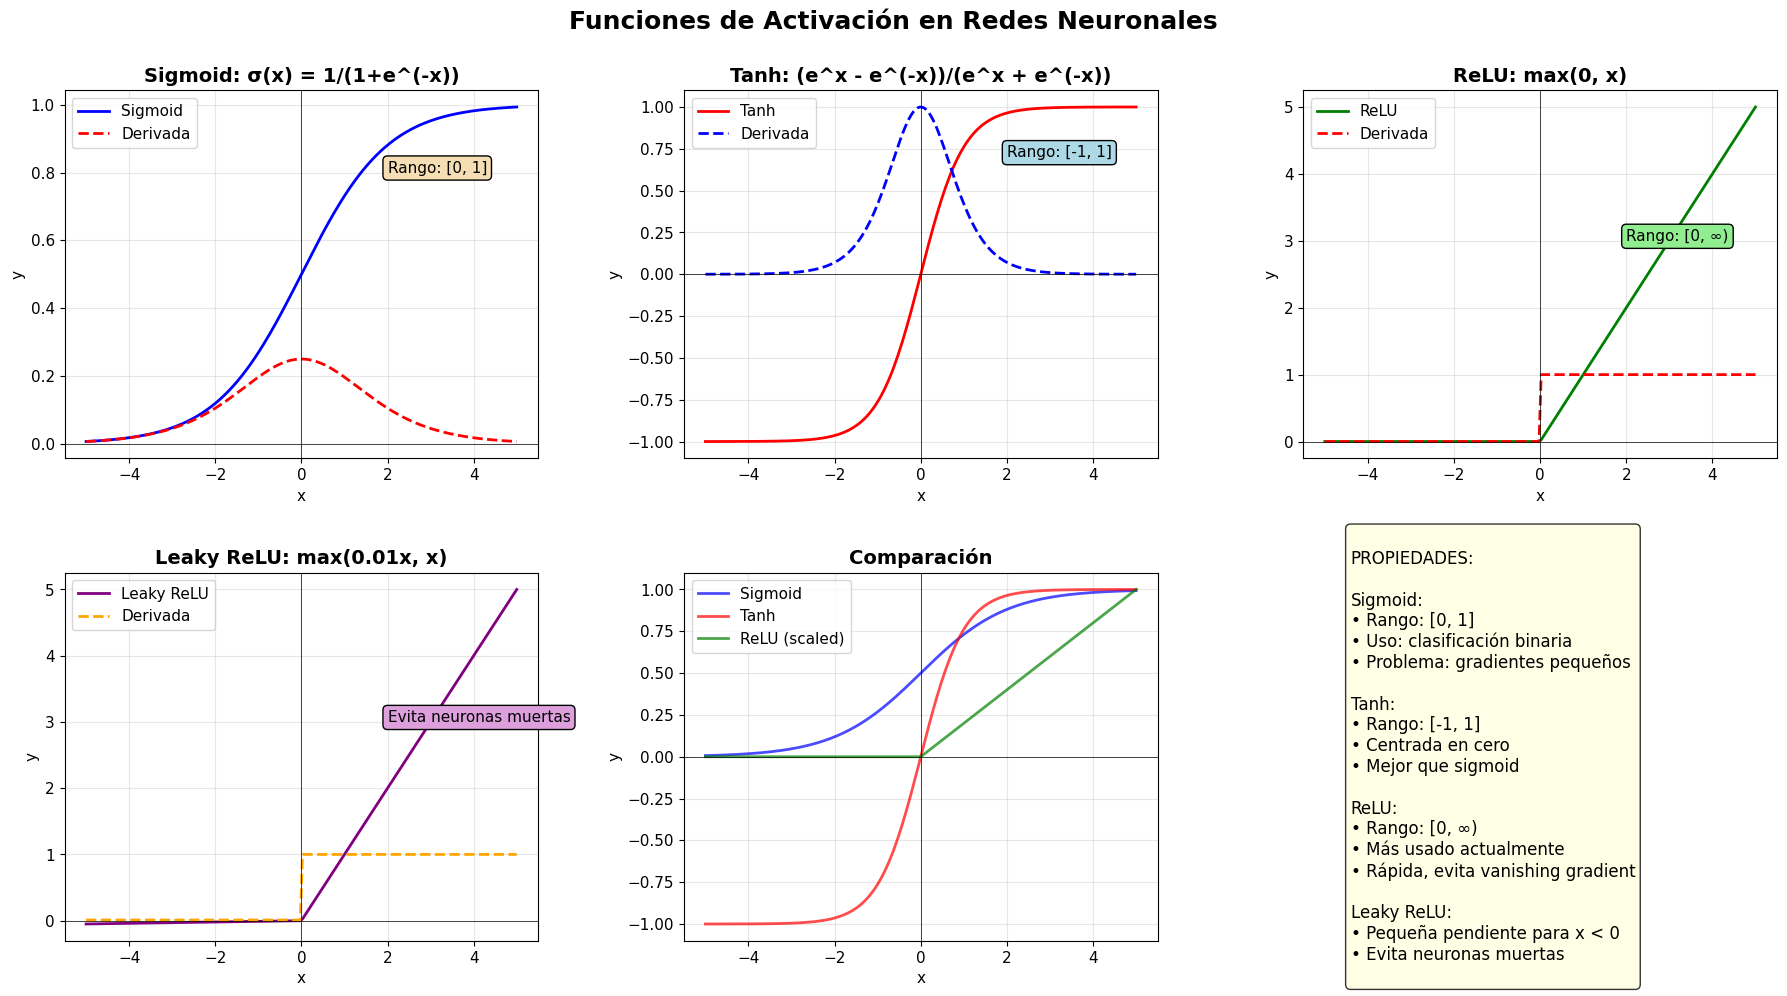


OBSERVACIONES CLAVE:
→ Sigmoid: Usado históricamente, pero tiene vanishing gradient
→ Tanh: Mejor que sigmoid, centrada en cero
→ ReLU: Estándar actual, rápida y efectiva
→ Leaky ReLU: Versión mejorada de ReLU


In [7]:
# Visualizar todas las funciones de activación

x = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sigmoid
axes[0, 0].plot(x, sigmoid(x), 'b-', linewidth=2, label='Sigmoid')
axes[0, 0].plot(x, sigmoid_derivative(x), 'r--', linewidth=2, label="Derivada")
axes[0, 0].axhline(0, color='k', linestyle='-', linewidth=0.5)
axes[0, 0].axvline(0, color='k', linestyle='-', linewidth=0.5)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_title('Sigmoid: σ(x) = 1/(1+e^(-x))', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].legend()
axes[0, 0].text(2, 0.8, 'Rango: [0, 1]', bbox=dict(boxstyle='round', facecolor='wheat'))

# Tanh
axes[0, 1].plot(x, tanh(x), 'r-', linewidth=2, label='Tanh')
axes[0, 1].plot(x, tanh_derivative(x), 'b--', linewidth=2, label='Derivada')
axes[0, 1].axhline(0, color='k', linestyle='-', linewidth=0.5)
axes[0, 1].axvline(0, color='k', linestyle='-', linewidth=0.5)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_title('Tanh: (e^x - e^(-x))/(e^x + e^(-x))', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('y')
axes[0, 1].legend()
axes[0, 1].text(2, 0.7, 'Rango: [-1, 1]', bbox=dict(boxstyle='round', facecolor='lightblue'))

# ReLU
axes[0, 2].plot(x, relu(x), 'g-', linewidth=2, label='ReLU')
axes[0, 2].plot(x, relu_derivative(x), 'r--', linewidth=2, label='Derivada')
axes[0, 2].axhline(0, color='k', linestyle='-', linewidth=0.5)
axes[0, 2].axvline(0, color='k', linestyle='-', linewidth=0.5)
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_title('ReLU: max(0, x)', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('x')
axes[0, 2].set_ylabel('y')
axes[0, 2].legend()
axes[0, 2].text(2, 3, 'Rango: [0, ∞)', bbox=dict(boxstyle='round', facecolor='lightgreen'))

# Leaky ReLU
axes[1, 0].plot(x, leaky_relu(x), 'purple', linewidth=2, label='Leaky ReLU')
axes[1, 0].plot(x, leaky_relu_derivative(x), 'orange', linestyle='--', linewidth=2, label='Derivada')
axes[1, 0].axhline(0, color='k', linestyle='-', linewidth=0.5)
axes[1, 0].axvline(0, color='k', linestyle='-', linewidth=0.5)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_title('Leaky ReLU: max(0.01x, x)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('y')
axes[1, 0].legend()
axes[1, 0].text(2, 3, 'Evita neuronas muertas', bbox=dict(boxstyle='round', facecolor='plum'))

# Comparación
axes[1, 1].plot(x, sigmoid(x), 'b-', linewidth=2, label='Sigmoid', alpha=0.7)
axes[1, 1].plot(x, tanh(x), 'r-', linewidth=2, label='Tanh', alpha=0.7)
axes[1, 1].plot(x, relu(x)/5, 'g-', linewidth=2, label='ReLU (scaled)', alpha=0.7)
axes[1, 1].axhline(0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].axvline(0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_title('Comparación', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('y')
axes[1, 1].legend()

# Propiedades
axes[1, 2].axis('off')
properties_text = """
PROPIEDADES:

Sigmoid:
• Rango: [0, 1]
• Uso: clasificación binaria
• Problema: gradientes pequeños

Tanh:
• Rango: [-1, 1]
• Centrada en cero
• Mejor que sigmoid

ReLU:
• Rango: [0, ∞)
• Más usado actualmente
• Rápida, evita vanishing gradient

Leaky ReLU:
• Pequeña pendiente para x < 0
• Evita neuronas muertas
"""
axes[1, 2].text(0.1, 0.5, properties_text, fontsize=12, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Funciones de Activación en Redes Neuronales', fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nOBSERVACIONES CLAVE:")
print("→ Sigmoid: Usado históricamente, pero tiene vanishing gradient")
print("→ Tanh: Mejor que sigmoid, centrada en cero")
print("→ ReLU: Estándar actual, rápida y efectiva")
print("→ Leaky ReLU: Versión mejorada de ReLU")

### 2.3 Implementación de Perceptrón Simple

In [8]:
class Perceptron:
    """
    Perceptrón simple implementado desde cero.

    Ecuación: y = σ(w·x + b)
    """

    def __init__(self, input_size, activation='sigmoid', learning_rate=0.01):
        """
        Args:
            input_size: Número de features de entrada
            activation: Función de activación ('sigmoid', 'tanh', 'relu')
            learning_rate: Tasa de aprendizaje
        """
        # Inicializar pesos aleatorios pequeños
        self.weights = np.random.randn(input_size) * 0.01
        self.bias = 0.0
        self.learning_rate = learning_rate

        # Seleccionar función de activación
        if activation == 'sigmoid':
            self.activation = sigmoid
            self.activation_derivative = sigmoid_derivative
        elif activation == 'tanh':
            self.activation = tanh
            self.activation_derivative = tanh_derivative
        elif activation == 'relu':
            self.activation = relu
            self.activation_derivative = relu_derivative
        else:
            raise ValueError(f"Activación no soportada: {activation}")

    def forward(self, x):
        """
        Forward pass: calcular predicción

        Args:
            x: Input (n_samples, n_features)

        Returns:
            y: Predicción (n_samples,)
        """
        # z = w·x + b
        self.z = np.dot(x, self.weights) + self.bias

        # y = f(z)
        self.output = self.activation(self.z)

        return self.output

    def compute_loss(self, y_true, y_pred):
        """
        Calcular Binary Cross-Entropy Loss
        """
        # Evitar log(0)
        epsilon = 1e-10
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        loss = -np.mean(
            y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
        )

        return loss

    def backward(self, x, y_true):
        """
        Backward pass: calcular gradientes

        Args:
            x: Input
            y_true: Labels verdaderos
        """
        n_samples = x.shape[0]

        # Gradiente de la pérdida respecto al output
        dL_dy = self.output - y_true

        # Gradiente respecto a z (regla de la cadena)
        dy_dz = self.activation_derivative(self.z)
        dL_dz = dL_dy * dy_dz

        # Gradientes respecto a pesos y bias
        self.dL_dw = np.dot(x.T, dL_dz) / n_samples
        self.dL_db = np.mean(dL_dz)

    def update_weights(self):
        """
        Actualizar pesos usando gradient descent
        """
        self.weights -= self.learning_rate * self.dL_dw
        self.bias -= self.learning_rate * self.dL_db

    def train(self, X, y, epochs=100, verbose=True):
        """
        Entrenar el perceptrón

        Args:
            X: Training data (n_samples, n_features)
            y: Labels (n_samples,)
            epochs: Número de épocas
            verbose: Mostrar progreso

        Returns:
            history: Historial de pérdidas
        """
        history = {'loss': []}

        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)

            # Calcular pérdida
            loss = self.compute_loss(y, y_pred)
            history['loss'].append(loss)

            # Backward pass
            self.backward(X, y)

            # Actualizar pesos
            self.update_weights()

            # Mostrar progreso
            if verbose and (epoch + 1) % 10 == 0:
                accuracy = np.mean((y_pred > 0.5) == y)
                print(f"Época [{epoch+1}/{epochs}] - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

        return history

    def predict(self, X, threshold=0.5):
        """
        Hacer predicciones
        """
        y_pred = self.forward(X)
        return (y_pred > threshold).astype(int)

print("Clase Perceptron implementada")

Clase Perceptron implementada


### 2.4 Entrenar Perceptrón con Datos Sintéticos

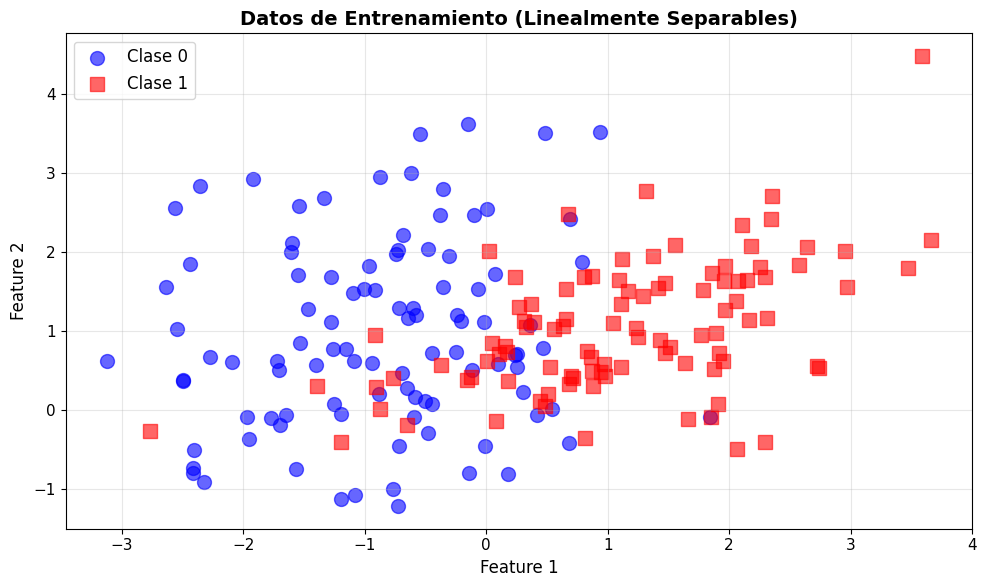


Datos generados:
  Muestras totales: 200
  Features: 2
  Clase 0: 100 muestras
  Clase 1: 100 muestras


In [31]:
# Generar datos sintéticos linealmente separables
np.random.seed(42)
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Visualizar datos
plt.figure(figsize=(10, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', marker='o', s=100, alpha=0.6, label='Clase 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', marker='s', s=100, alpha=0.6, label='Clase 1')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Datos de Entrenamiento (Linealmente Separables)', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDatos generados:")
print(f"  Muestras totales: {X.shape[0]}")
print(f"  Features: {X.shape[1]}")
print(f"  Clase 0: {np.sum(y==0)} muestras")
print(f"  Clase 1: {np.sum(y==1)} muestras")

In [10]:
# Entrenar perceptrón
print("\nENTRENANDO PERCEPTRÓN")

perceptron = Perceptron(
    input_size=2,
    activation='sigmoid',
    learning_rate=0.1
)

history = perceptron.train(X, y, epochs=100, verbose=True)

print("Entrenamiento completado")


ENTRENANDO PERCEPTRÓN
Época [10/100] - Loss: 0.6412, Accuracy: 0.8550
Época [20/100] - Loss: 0.5990, Accuracy: 0.8550
Época [30/100] - Loss: 0.5668, Accuracy: 0.8550
Época [40/100] - Loss: 0.5419, Accuracy: 0.8500
Época [50/100] - Loss: 0.5221, Accuracy: 0.8550
Época [60/100] - Loss: 0.5060, Accuracy: 0.8500
Época [70/100] - Loss: 0.4927, Accuracy: 0.8500
Época [80/100] - Loss: 0.4816, Accuracy: 0.8500
Época [90/100] - Loss: 0.4721, Accuracy: 0.8500
Época [100/100] - Loss: 0.4639, Accuracy: 0.8500
Entrenamiento completado


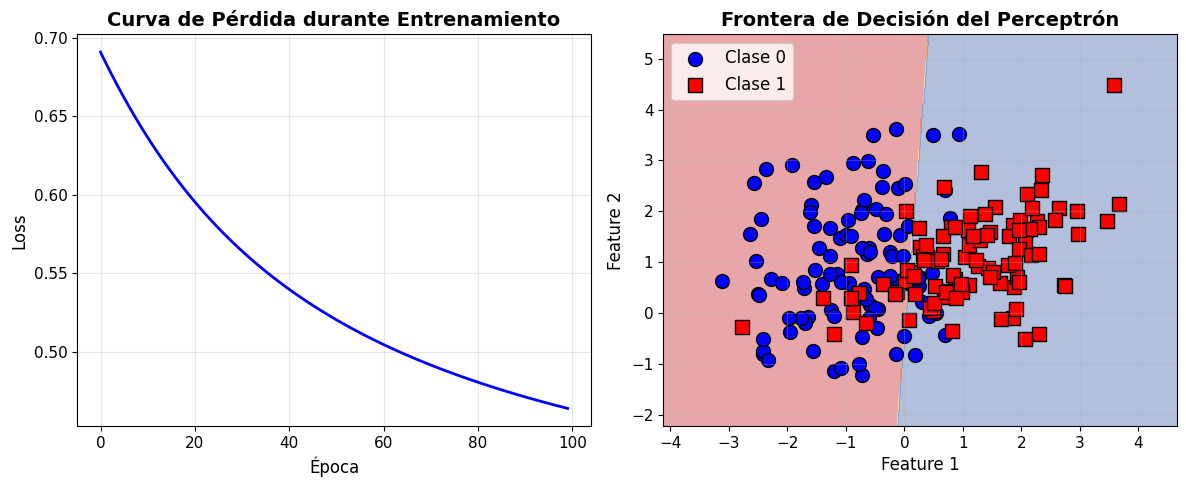


Accuracy final: 0.8500 (85.00%)


In [11]:
# Visualizar curva de pérdida
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], linewidth=2, color='blue')
plt.xlabel('Época', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Curva de Pérdida durante Entrenamiento', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Visualizar frontera de decisión
plt.subplot(1, 2, 2)

# Crear malla
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predecir en cada punto de la malla
Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contorno
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', marker='o', s=100, edgecolors='k', label='Clase 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', marker='s', s=100, edgecolors='k', label='Clase 1')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Frontera de Decisión del Perceptrón', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular accuracy final
y_pred = perceptron.predict(X)
accuracy = np.mean(y_pred == y)
print(f"\nAccuracy final: {accuracy:.4f} ({accuracy*100:.2f}%)")

---

## PARTE 3: PyTorch Fundamentals

### 3.1 Tensores en PyTorch

In [13]:
print("TENSORES EN PYTORCH")

# Crear tensores de diferentes maneras
print("\n1. Creación de tensores:")

# Desde lista
t1 = torch.tensor([1, 2, 3, 4, 5])
print(f"Desde lista: {t1}")
print(f"  Shape: {t1.shape}, dtype: {t1.dtype}")

# Ceros y unos
zeros = torch.zeros(3, 4)
ones = torch.ones(2, 3)
print(f"\nCeros (3x4):\n{zeros}")
print(f"\nUnos (2x3):\n{ones}")

# Aleatorios
rand = torch.rand(2, 3)  # Uniforme [0, 1]
randn = torch.randn(2, 3)  # Normal (0, 1)
print(f"\nAleatorio uniforme (2x3):\n{rand}")
print(f"\nAleatorio normal (2x3):\n{randn}")

# Secuencias
seq = torch.arange(0, 10, 2)
linspace = torch.linspace(0, 1, 5)
print(f"\nSecuencia [0, 10) paso 2: {seq}")
print(f"Linspace [0, 1] 5 puntos: {linspace}")


TENSORES EN PYTORCH

1. Creación de tensores:
Desde lista: tensor([1, 2, 3, 4, 5])
  Shape: torch.Size([5]), dtype: torch.int64

Ceros (3x4):
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

Unos (2x3):
tensor([[1., 1., 1.],
        [1., 1., 1.]])

Aleatorio uniforme (2x3):
tensor([[0.0960, 0.9123, 0.1026],
        [0.7538, 0.6381, 0.0622]])

Aleatorio normal (2x3):
tensor([[-0.2301,  1.4522,  2.3854],
        [-1.3377, -1.3157,  0.1413]])

Secuencia [0, 10) paso 2: tensor([0, 2, 4, 6, 8])
Linspace [0, 1] 5 puntos: tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


In [14]:
print("\n2. Operaciones con tensores:")

# Operaciones aritméticas
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print(f"a = {a}")
print(f"b = {b}")
print(f"\na + b = {a + b}")
print(f"a * b = {a * b}")
print(f"a ** 2 = {a ** 2}")

# Operaciones matriciales
A = torch.randn(3, 4)
B = torch.randn(4, 5)
C = torch.mm(A, B)  # Multiplicación matricial

print(f"\nA shape: {A.shape}")
print(f"B shape: {B.shape}")
print(f"A @ B shape: {C.shape}")

# Reducción
x = torch.randn(3, 4)
print(f"\nTensor x:\n{x}")
print(f"Suma total: {x.sum()}")
print(f"Media: {x.mean()}")
print(f"Max: {x.max()}")
print(f"Suma por filas: {x.sum(dim=1)}")
print(f"Media por columnas: {x.mean(dim=0)}")



2. Operaciones con tensores:
a = tensor([1., 2., 3.])
b = tensor([4., 5., 6.])

a + b = tensor([5., 7., 9.])
a * b = tensor([ 4., 10., 18.])
a ** 2 = tensor([1., 4., 9.])

A shape: torch.Size([3, 4])
B shape: torch.Size([4, 5])
A @ B shape: torch.Size([3, 5])

Tensor x:
tensor([[-0.4163,  0.9620, -0.7024,  2.3185],
        [ 2.2436, -0.2926, -0.5984,  0.7537],
        [ 0.2992, -1.6412, -1.5910,  0.3313]])
Suma total: 1.666482925415039
Media: 0.13887357711791992
Max: 2.3185129165649414
Suma por filas: tensor([ 2.1619,  2.1063, -2.6017])
Media por columnas: tensor([ 0.7088, -0.3239, -0.9639,  1.1345])


In [15]:
print("\n3. Reshape y manipulación:")

# Reshape
x = torch.arange(12)
print(f"Original: {x}")
print(f"  Shape: {x.shape}")

x_2d = x.reshape(3, 4)
print(f"\nReshape (3, 4):\n{x_2d}")

x_3d = x.reshape(2, 2, 3)
print(f"\nReshape (2, 2, 3):\n{x_3d}")

# View (similar a reshape pero comparte memoria)
x_view = x.view(4, 3)
print(f"\nView (4, 3):\n{x_view}")

# Transpose
A = torch.randn(3, 5)
AT = A.T  # o A.transpose(0, 1)
print(f"\nA shape: {A.shape}")
print(f"A^T shape: {AT.shape}")

# Squeeze y unsqueeze (eliminar/añadir dimensiones)
x = torch.randn(1, 3, 1, 4)
print(f"\nOriginal shape: {x.shape}")
print(f"Squeeze: {x.squeeze().shape}")  # Elimina dimensiones de tamaño 1
print(f"Unsqueeze(0): {x.unsqueeze(0).shape}")  # Añade dimensión en posición 0



3. Reshape y manipulación:
Original: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
  Shape: torch.Size([12])

Reshape (3, 4):
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

Reshape (2, 2, 3):
tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]]])

View (4, 3):
tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])

A shape: torch.Size([3, 5])
A^T shape: torch.Size([5, 3])

Original shape: torch.Size([1, 3, 1, 4])
Squeeze: torch.Size([3, 4])
Unsqueeze(0): torch.Size([1, 1, 3, 1, 4])


### 3.2 Autograd: Diferenciación Automática

In [16]:
print("AUTOGRAD: DIFERENCIACIÓN AUTOMÁTICA")

# Ejemplo 1: Derivada simple
print("\n1. Derivada de y = x^2 + 3x + 1")

x = torch.tensor(2.0, requires_grad=True)
print(f"x = {x.item()}")

# Forward pass
y = x**2 + 3*x + 1
print(f"y = x^2 + 3x + 1 = {y.item()}")

# Backward pass
y.backward()

# Ver gradiente
print(f"\ndy/dx = 2x + 3")
print(f"Calculado manualmente: dy/dx = 2*{x.item()} + 3 = {2*x.item() + 3}")
print(f"Calculado por autograd: dy/dx = {x.grad.item()}")
print(f"Coinciden")


AUTOGRAD: DIFERENCIACIÓN AUTOMÁTICA

1. Derivada de y = x^2 + 3x + 1
x = 2.0
y = x^2 + 3x + 1 = 11.0

dy/dx = 2x + 3
Calculado manualmente: dy/dx = 2*2.0 + 3 = 7.0
Calculado por autograd: dy/dx = 7.0
Coinciden


In [17]:
# Ejemplo 2: Gradientes con vectores
print("\n2. Gradientes con vectores")

x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
print(f"x = {x}")

# Operación vectorial
y = x**2
print(f"y = x^2 = {y}")

# Necesitamos un escalar para backward
z = y.sum()
print(f"z = sum(y) = {z.item()}")

# Backward
z.backward()

print(f"\ndz/dx = [dz/dx1, dz/dx2, dz/dx3]")
print(f"Teóricamente: dz/dx = [2*x1, 2*x2, 2*x3] = [2*1, 2*2, 2*3] = [2, 4, 6]")
print(f"Autograd: dz/dx = {x.grad}")
print(f"Coinciden")



2. Gradientes con vectores
x = tensor([1., 2., 3.], requires_grad=True)
y = x^2 = tensor([1., 4., 9.], grad_fn=<PowBackward0>)
z = sum(y) = 14.0

dz/dx = [dz/dx1, dz/dx2, dz/dx3]
Teóricamente: dz/dx = [2*x1, 2*x2, 2*x3] = [2*1, 2*2, 2*3] = [2, 4, 6]
Autograd: dz/dx = tensor([2., 4., 6.])
Coinciden


In [18]:
# Ejemplo 3: Red neuronal simple con autograd
print("\n3. Perceptrón simple con autograd")

# Input
x = torch.tensor([1.0, 2.0], requires_grad=False)
print(f"Input x: {x}")

# Pesos (requieren gradientes)
w = torch.tensor([0.5, -0.3], requires_grad=True)
b = torch.tensor(0.1, requires_grad=True)
print(f"Pesos w: {w}")
print(f"Bias b: {b}")

# Forward pass
z = torch.dot(x, w) + b
y = torch.sigmoid(z)
print(f"\nForward:")
print(f"  z = w·x + b = {z.item():.4f}")
print(f"  y = σ(z) = {y.item():.4f}")

# Target
target = torch.tensor(1.0)
loss = (y - target)**2
print(f"\nLoss = (y - target)^2 = {loss.item():.4f}")

# Backward
loss.backward()

print(f"\nGradientes:")
print(f"  dL/dw = {w.grad}")
print(f"  dL/db = {b.grad.item():.4f}")

print("\nEstos gradientes se usan para actualizar w y b")



3. Perceptrón simple con autograd
Input x: tensor([1., 2.])
Pesos w: tensor([ 0.5000, -0.3000], requires_grad=True)
Bias b: 0.10000000149011612

Forward:
  z = w·x + b = -0.0000
  y = σ(z) = 0.5000

Loss = (y - target)^2 = 0.2500

Gradientes:
  dL/dw = tensor([-0.2500, -0.5000])
  dL/db = -0.2500

Estos gradientes se usan para actualizar w y b


### 3.3 GPU Acceleration

In [20]:
print("GPU ACCELERATION")

# Verificar disponibilidad
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA version: {torch.version.cuda}")
    print(f"   Memoria GPU total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    device = torch.device('cpu')
    print("GPU no disponible, usando CPU")

print(f"\nDispositivo seleccionado: {device}")

# Mover tensores a GPU
if torch.cuda.is_available():
    print("\nEjemplo de uso:")

    # CPU
    x_cpu = torch.randn(1000, 1000)
    print(f"  Tensor en CPU: {x_cpu.device}")

    # GPU
    x_gpu = x_cpu.to(device)
    # o x_gpu = x_cpu.cuda()
    print(f"  Tensor en GPU: {x_gpu.device}")

    # Operación en GPU
    import time

    # CPU
    start = time.time()
    result_cpu = torch.mm(x_cpu, x_cpu)
    cpu_time = time.time() - start

    # GPU
    start = time.time()
    result_gpu = torch.mm(x_gpu, x_gpu)
    torch.cuda.synchronize()  # Esperar a que termine
    gpu_time = time.time() - start

    print(f"\nMultiplicación de matrices (1000x1000):")
    print(f"  CPU: {cpu_time:.4f} segundos")
    print(f"  GPU: {gpu_time:.4f} segundos")


GPU ACCELERATION
GPU disponible: Tesla T4
   CUDA version: 12.8
   Memoria GPU total: 15.64 GB

Dispositivo seleccionado: cuda

Ejemplo de uso:
  Tensor en CPU: cpu
  Tensor en GPU: cuda:0

Multiplicación de matrices (1000x1000):
  CPU: 0.0169 segundos
  GPU: 0.0009 segundos


---

## PARTE 4: Primera Red Neuronal con PyTorch

### 4.1 Definir Modelo con nn.Module

In [2]:
import torch.nn as nn

In [3]:
class SimpleNN(nn.Module):
    """
    Red neuronal simple con:
    - 1 capa oculta
    - Activación ReLU
    - Output para clasificación binaria
    """

    def __init__(self, input_size, hidden_size, output_size):
        """
        Args:
            input_size: Número de features de entrada
            hidden_size: Número de neuronas en capa oculta
            output_size: Número de clases de salida
        """
        super(SimpleNN, self).__init__()

        # Definir capas
        self.fc1 = nn.Linear(input_size, hidden_size)  # Fully connected 1
        self.relu = nn.ReLU()  # Activación
        self.fc2 = nn.Linear(hidden_size, output_size)  # Output layer

    def forward(self, x):
        """
        Forward pass

        Args:
            x: Input tensor (batch_size, input_size)

        Returns:
            out: Output tensor (batch_size, output_size)
        """
        # Layer 1
        out = self.fc1(x)
        out = self.relu(out)

        # Output layer
        out = self.fc2(out)

        return out

    def num_parameters(self):
        """
        Contar número total de parámetros
        """
        return sum(p.numel() for p in self.parameters())

# Crear modelo
model = SimpleNN(input_size=2, hidden_size=10, output_size=2)

print("RED NEURONAL CREADA")
print(model)
print(f"\nNúmero total de parámetros: {model.num_parameters()}")

# Detallar parámetros por capa
print("\nParámetros por capa:")
for name, param in model.named_parameters():
    print(f"  {name}: {param.shape} → {param.numel()} parámetros")


RED NEURONAL CREADA
SimpleNN(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=10, out_features=2, bias=True)
)

Número total de parámetros: 52

Parámetros por capa:
  fc1.weight: torch.Size([10, 2]) → 20 parámetros
  fc1.bias: torch.Size([10]) → 10 parámetros
  fc2.weight: torch.Size([2, 10]) → 20 parámetros
  fc2.bias: torch.Size([2]) → 2 parámetros


### 4.2 Preparar Datos

GENERANDO DATOS DE ENTRENAMIENTO

Datos preparados:
  Train: 400 muestras
  Test: 100 muestras
  Features: 2
  Clases: 2


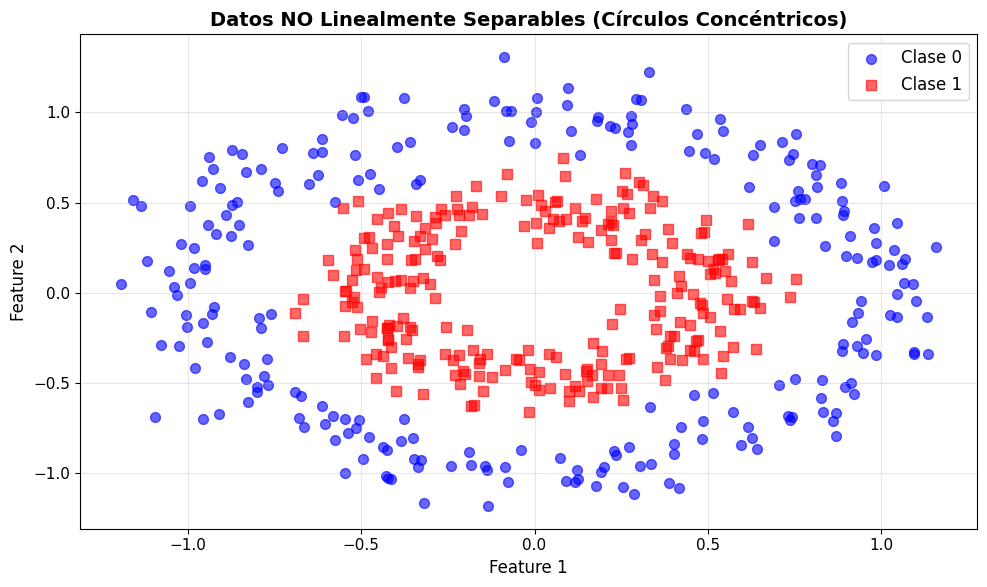


Un perceptrón simple NO puede separar estos datos
   Necesitamos una red neuronal con capas ocultas


In [23]:
# Generar dataset NO linealmente separable (círculos)
print("GENERANDO DATOS DE ENTRENAMIENTO")

np.random.seed(42)
X_np, y_np = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)

# Convertir a tensores de PyTorch
X_tensor = torch.FloatTensor(X_np)
y_tensor = torch.LongTensor(y_np)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

print(f"\nDatos preparados:")
print(f"  Train: {X_train.shape[0]} muestras")
print(f"  Test: {X_test.shape[0]} muestras")
print(f"  Features: {X_train.shape[1]}")
print(f"  Clases: {len(torch.unique(y_train))}")

# Visualizar
plt.figure(figsize=(10, 6))
plt.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1], c='blue', marker='o', s=50, alpha=0.6, label='Clase 0')
plt.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1], c='red', marker='s', s=50, alpha=0.6, label='Clase 1')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Datos NO Linealmente Separables (Círculos Concéntricos)', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nUn perceptrón simple NO puede separar estos datos")
print("   Necesitamos una red neuronal con capas ocultas")

### 4.3 Entrenar el Modelo

In [24]:
# Configurar entrenamiento
model = SimpleNN(input_size=2, hidden_size=20, output_size=2)

# Mover a GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# Loss y optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("CONFIGURACIÓN DEL ENTRENAMIENTO")
print(f"Modelo: SimpleNN(2 → 20 → 2)")
print(f"Dispositivo: {device}")
print(f"Loss: CrossEntropyLoss")
print(f"Optimizer: Adam (lr=0.01)")
print(f"Parámetros totales: {model.num_parameters()}")

# Training loop
epochs = 200
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

print("\nINICIANDO ENTRENAMIENTO...\n")

for epoch in range(epochs):
    # Training mode
    model.train()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward pass
    optimizer.zero_grad()  # Limpiar gradientes anteriores
    loss.backward()  # Calcular gradientes
    optimizer.step()  # Actualizar pesos

    # Calcular accuracy
    _, predicted = torch.max(outputs.data, 1)
    train_acc = (predicted == y_train).float().mean()

    # Evaluation mode
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)
        _, test_predicted = torch.max(test_outputs.data, 1)
        test_acc = (test_predicted == y_test).float().mean()

    # Guardar historial
    history['train_loss'].append(loss.item())
    history['train_acc'].append(train_acc.item())
    history['test_loss'].append(test_loss.item())
    history['test_acc'].append(test_acc.item())

    # Mostrar progreso
    if (epoch + 1) % 20 == 0:
        print(f"Época [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {loss.item():.4f}, Train Acc: {train_acc.item():.4f}")
        print(f"  Test Loss: {test_loss.item():.4f}, Test Acc: {test_acc.item():.4f}")
        print()

print("ENTRENAMIENTO COMPLETADO")
print(f"\nAccuracy final:")
print(f"  Train: {history['train_acc'][-1]:.4f} ({history['train_acc'][-1]*100:.2f}%)")
print(f"  Test: {history['test_acc'][-1]:.4f} ({history['test_acc'][-1]*100:.2f}%)")

CONFIGURACIÓN DEL ENTRENAMIENTO
Modelo: SimpleNN(2 → 20 → 2)
Dispositivo: cuda
Loss: CrossEntropyLoss
Optimizer: Adam (lr=0.01)
Parámetros totales: 102

INICIANDO ENTRENAMIENTO...

Época [20/200]
  Train Loss: 0.5526, Train Acc: 0.9600
  Test Loss: 0.5714, Test Acc: 0.9200

Época [40/200]
  Train Loss: 0.3921, Train Acc: 0.9675
  Test Loss: 0.4077, Test Acc: 0.9600

Época [60/200]
  Train Loss: 0.2512, Train Acc: 0.9625
  Test Loss: 0.2497, Test Acc: 0.9700

Época [80/200]
  Train Loss: 0.1626, Train Acc: 0.9825
  Test Loss: 0.1555, Test Acc: 0.9900

Época [100/200]
  Train Loss: 0.1137, Train Acc: 0.9850
  Test Loss: 0.1096, Test Acc: 0.9900

Época [120/200]
  Train Loss: 0.0870, Train Acc: 0.9875
  Test Loss: 0.0844, Test Acc: 0.9800

Época [140/200]
  Train Loss: 0.0705, Train Acc: 0.9900
  Test Loss: 0.0693, Test Acc: 0.9800

Época [160/200]
  Train Loss: 0.0596, Train Acc: 0.9925
  Test Loss: 0.0593, Test Acc: 0.9800

Época [180/200]
  Train Loss: 0.0509, Train Acc: 0.9925
  Test 

### 4.4 Visualizar Resultados

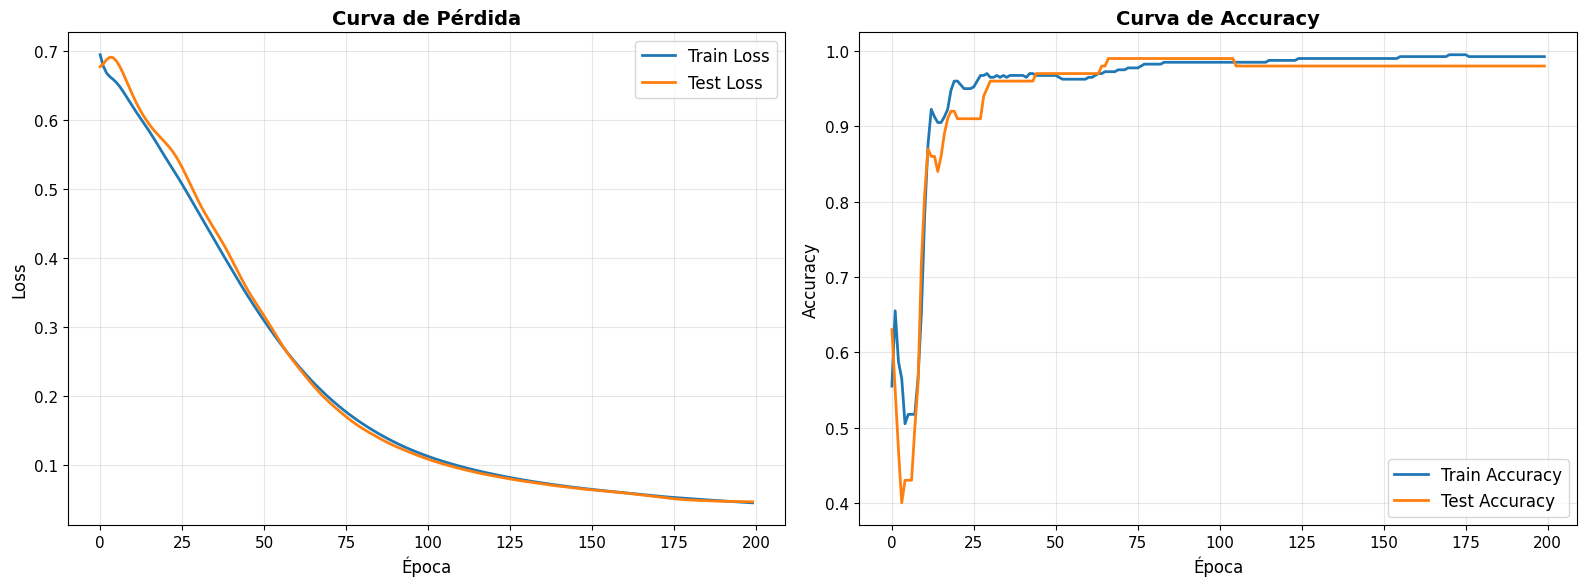

In [25]:
# Visualizar curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['test_loss'], label='Test Loss', linewidth=2)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Curva de Pérdida', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(history['test_acc'], label='Test Accuracy', linewidth=2)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Curva de Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


VISUALIZANDO FRONTERA DE DECISIÓN


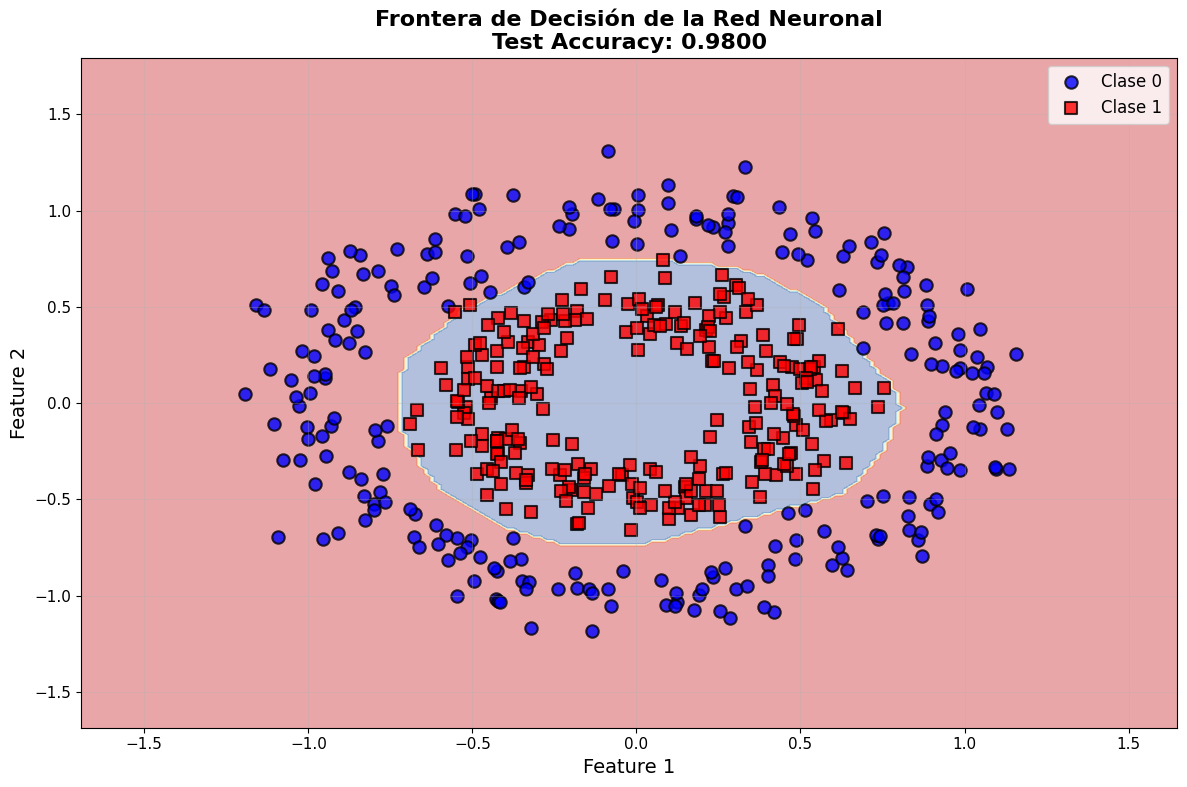


La red neuronal aprendió a separar círculos concéntricos
 Algo que un perceptrón simple NO puede hacer


In [26]:
# Visualizar frontera de decisión
print("\nVISUALIZANDO FRONTERA DE DECISIÓN")

# Mover modelo y datos a CPU para visualización
model_cpu = model.cpu()
X_np = X_tensor.numpy()
y_np = y_tensor.numpy()

# Crear malla
h = 0.02
x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predecir en cada punto
model_cpu.eval()
with torch.no_grad():
    mesh_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    Z = model_cpu(mesh_tensor)
    _, Z = torch.max(Z, 1)
    Z = Z.numpy()

Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
plt.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1],
            c='blue', marker='o', s=80, edgecolors='k', linewidth=1.5, label='Clase 0', alpha=0.8)
plt.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1],
            c='red', marker='s', s=80, edgecolors='k', linewidth=1.5, label='Clase 1', alpha=0.8)
plt.xlabel('Feature 1', fontsize=14)
plt.ylabel('Feature 2', fontsize=14)
plt.title(f'Frontera de Decisión de la Red Neuronal\nTest Accuracy: {history["test_acc"][-1]:.4f}',
          fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nLa red neuronal aprendió a separar círculos concéntricos")
print(" Algo que un perceptrón simple NO puede hacer")

---

## PARTE 5: Comparación Perceptrón vs Red Neuronal

### 5.1 Entrenar Perceptrón en el Mismo Dataset

In [27]:
print("COMPARACIÓN: PERCEPTRÓN vs RED NEURONAL")

# Entrenar perceptrón simple
print("\n1. Entrenando Perceptrón Simple...")
perceptron = Perceptron(input_size=2, activation='sigmoid', learning_rate=0.1)
perc_history = perceptron.train(X_np, y_np, epochs=200, verbose=False)
y_pred_perc = perceptron.predict(X_np)
perc_acc = np.mean(y_pred_perc == y_np)
print(f"   Accuracy Perceptrón: {perc_acc:.4f} ({perc_acc*100:.2f}%)")

print(f"\n2. Red Neuronal (ya entrenada)")
nn_acc = history['test_acc'][-1]
print(f"   Accuracy Red Neuronal: {nn_acc:.4f} ({nn_acc*100:.2f}%)")

print(f"\nCOMPARACIÓN:")
print(f"{'Modelo':<20} {'Accuracy':<15} {'Parámetros'}")
print(f"{'Perceptrón':<20} {f'{perc_acc:.4f} ({perc_acc*100:.1f}%)':<15} 3")
print(f"{'Red Neuronal':<20} {f'{nn_acc:.4f} ({nn_acc*100:.1f}%)':<15} {model.num_parameters()}")

print(f"\nMejora: {(nn_acc - perc_acc)*100:.2f} puntos porcentuales")


COMPARACIÓN: PERCEPTRÓN vs RED NEURONAL

1. Entrenando Perceptrón Simple...
   Accuracy Perceptrón: 0.4900 (49.00%)

2. Red Neuronal (ya entrenada)
   Accuracy Red Neuronal: 0.9800 (98.00%)

COMPARACIÓN:
Modelo               Accuracy        Parámetros
Perceptrón           0.4900 (49.0%)  3
Red Neuronal         0.9800 (98.0%)  102

Mejora: 49.00 puntos porcentuales


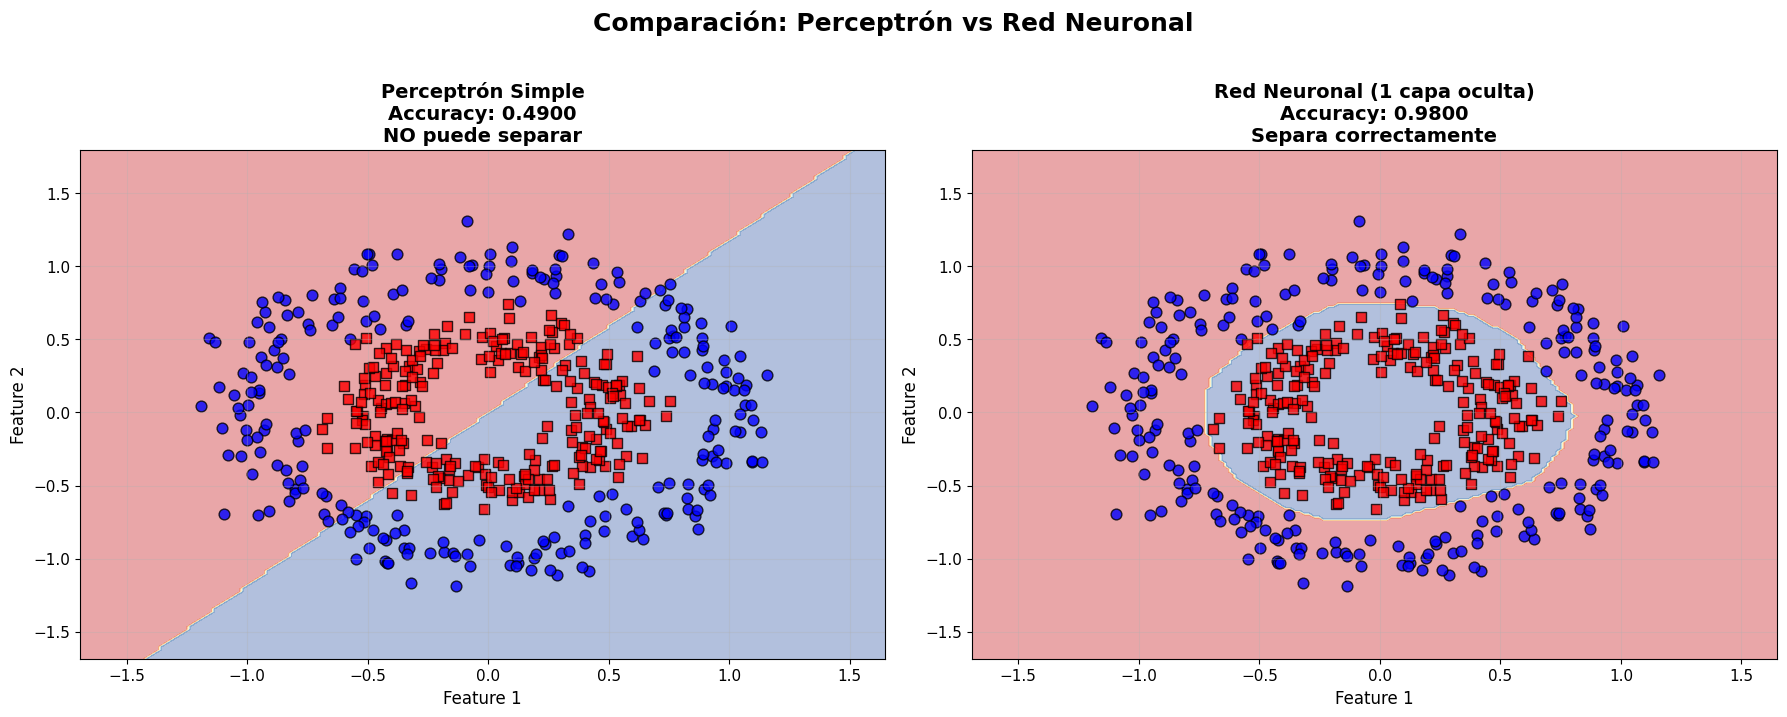


CONCLUSIÓN:
→ Perceptrón: Solo puede aprender funciones lineales
→ Red Neuronal: Puede aprender funciones NO lineales complejas
→ Las capas ocultas son ESENCIALES para problemas complejos


In [29]:
# Visualizar ambas fronteras de decisión
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Perceptrón
Z_perc = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
Z_perc = Z_perc.reshape(xx.shape)

axes[0].contourf(xx, yy, Z_perc, alpha=0.4, cmap=plt.cm.RdYlBu)
axes[0].scatter(X_np[y_np==0, 0], X_np[y_np==0, 1], c='blue', marker='o', s=60, edgecolors='k', alpha=0.8)
axes[0].scatter(X_np[y_np==1, 0], X_np[y_np==1, 1], c='red', marker='s', s=60, edgecolors='k', alpha=0.8)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].set_title(f'Perceptrón Simple\nAccuracy: {perc_acc:.4f}\nNO puede separar',
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Red Neuronal
axes[1].contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
axes[1].scatter(X_np[y_np==0, 0], X_np[y_np==0, 1], c='blue', marker='o', s=60, edgecolors='k', alpha=0.8)
axes[1].scatter(X_np[y_np==1, 0], X_np[y_np==1, 1], c='red', marker='s', s=60, edgecolors='k', alpha=0.8)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].set_title(f'Red Neuronal (1 capa oculta)\nAccuracy: {nn_acc:.4f}\nSepara correctamente',
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparación: Perceptrón vs Red Neuronal', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nCONCLUSIÓN:")
print("→ Perceptrón: Solo puede aprender funciones lineales")
print("→ Red Neuronal: Puede aprender funciones NO lineales complejas")
print("→ Las capas ocultas son ESENCIALES para problemas complejos")

---

## PARTE 6: Resumen y Ejercicios


### 6.1 Preparación para Sesión 4

En la próxima sesión aprenderemos:

1. **Redes Neuronales Convolucionales (CNN)**
   - Operación de convolución
   - Filtros y feature maps
   - Pooling layers

2. **Arquitecturas CNN Clásicas**
   - LeNet, AlexNet, VGG
   - ResNet y skip connections

3. **Transfer Learning**
   - Usar modelos pre-entrenados
   - Fine-tuning
   - Feature extraction

---

## Recursos Adicionales

### Documentación:
- **PyTorch Docs:** https://pytorch.org/docs/
- **PyTorch Tutorials:** https://pytorch.org/tutorials/
- **Neural Networks from Scratch:** https://nnfs.io/

### Papers importantes:
- Rumelhart et al. (1986): "Learning representations by back-propagating errors"
- Goodfellow et al. (2016): "Deep Learning" book
- LeCun et al. (2015): "Deep learning" Nature review


---

**Profesor:** Guido Anthony Chipana Calderon  
**Sesión:** 3 de 12

---